# Προσομοιώσεις Πλεγμάτων Επιταχυντών με Python και Xsuite
# Μάθημα 1ο: Τα βασικά του tracking
#### Φυσική των Επιταχυντών
#### Μεταπτυχιακό Υποατομικής Φυσικής, 2o έτος
#### Τμήμα Φυσικής / Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης
#### Εαρινό εξάμηνο 2025 

*T. Prebibaj, F. Antoniou, F. Asvesta, Y. Papaphilippou*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

---
## 📌 Τυπολόγιο από την Θεωρία (Μάθημα 1 & 2)

### 🔹 Μαγνητική Ακαμψία (Magnetic Rigidity) (Μ1-δ46)
- Η μαγνητική ακαμψία δίνεται από τη σχέση:

    $
    B \rho = \frac{P}{q}
    $

    ή σε πρακτικές μονάδες:

    $
    B\rho \, [Tm] \approx 3.3356 \times p \, [GeV/c]
    $

### 🔹 Ισχυρή Κανονικοποιημένη Εστιακή Ισχύς (Strong Normalized Focusing Strength) (Μ1-δ53)
- Για τετράπολο με απόκλιση (gradient) \( g \):

    $
    k_1 = \frac{g}{B\rho} \quad [1/m^2]
    $


### 🔹 Εστιακό Μήκος (Focusing Length) (Μ1-δ53)
- Για τετράπολο μήκους $( l_q )$:

    $
    f = \frac{1}{k l_q} \quad [m]
    $


### 🔹 Ανάπτυγμα Μαγνητικών Πολυπόλων (Magnetic Multipole Expansion) (M1-δ60)
- Η περιγραφή του πεδίου μέσω ανάπτυγματος μαγνητικών πολυπόλων:

    $
    B(x,y) = B_y(x,y) + iB_x(x,y) = \sum_{n=0}^{\infty} (B_n + iA_n) (x + iy)^n
    $


---
## 📌 Σύστημα συντεταγμένων και αναπαράσταση σωματιδίων (Μ2-δ5)

### 🔹 Περιγραφή της Κίνησης Σωματιδίων στους Επιταχυντές  

<p align="center">
<img src=./images_lectures/frenet_system.png width="40%">
</p>

- Η κίνηση των σωματιδίων στους επιταχυντές περιγράφεται στο **σύστημα αναφοράς Frenet**.

- H δυναμική των φορτισμένων σωματιδίων περιγράφεται μέσω **Χαμιλτονιανής μηχανικής**, χρησιμοποιώντας **κανονικές συντεταγμένες**. Συνηθισμένες επιλογές είναι η **οριζόντια (ή κατακόρυφη) θέση** $x$ και η αντίστοιχη **κανονικοποιημένη ορμή** $p_x = P_x / P_0$, όπου $P_0$ είναι η ορμή αναφοράς.

- Οι συντεταγμένες του σωματιδίου στους τρεις βαθμούς ελευθερίας είναι συνήθως:  
  $$
  (x, p_x), \quad (y, p_y), \quad (z, \delta)
  $$
  όπου z η θέση του σωματιδίου στο διαμήκες επίπεδο και $\delta$ η απόκλιση της ορμής του σωματιδίου σε σχέση με την ορμή αναφοράς. 

- Σε αυτό το μάθημα, θα επικεντρωθούμε κυρίως στη **εγκαρσια δυναμική** (transverse dynamics), δηλαδή στην κίνηση στο **οριζόντιο $(x, p_x)$** ή **κατακόρυφο $(y, p_y)$** επίπεδο.

- Υποθέτοντας ότι οι τροχιές των σωματιδίων στο εγκάρσιο επίπεδο έχουν **μικρές αποκλίσεις και γωνίες** (π.χ. λιγότερο από μερικά mm και mrad) σε σχέση με την κίνηση στο διαμήκες, τότε μπορούμε να προσεγγίσουμε:

  $$
  p_x = \frac{P_x}{P_0} \approx \frac{P_x}{P_s} = \tan(x') \approx x'
  $$

  όπου $P_s$ είναι η ορμή κατά μήκος της διεύθυνσης της δέσμης και $x'$ είναι η γωνία του σωματιδίου ως προς τον άξονα $s$.  
  **Για το υπόλοιπο των διαλέξεων θα χρησιμοποιούμε αυτήν την προσέγγιση.**

### 📝 Άσκηση 1: αναπαράσταση ενός σωματιδίου σε Python

- Ένα μεμονωμένο σωματίδιο περιγράφεται από έναν διάνυσμα που περιέχει τις συντεταγμένες του στον φασικό χώρο $(x, x')$:

    $$
    \vec{x} = X =
    \begin{pmatrix}
    x \\
    x'
    \end{pmatrix}.
    $$

    **Εκφράστε σε Python ένα σωματίδιο στο οριζόντιο επίπεδο, το οποίο βρίσκεται στον οπτικό άξονα και έχει γωνία**  $x' = 0.5$ **mrad.**


In [2]:
X_0 = np.array( [ [0],    # initial position (usually in mm)
                  [0.5]]) # initial angle (usually in mrad)
print(f'Initial particle coordinates:\n {X_0}')

Initial particle coordinates:
 [[0. ]
 [0.5]]


### 📝 Άσκηση 2: αναπαράσταση πολλών σωματιδίων (δέσμης) σε Python  

- Οι συντεταγμένες φασικού χώρου για πολλά σωματίδια (π.χ. N ) μπορούν να συγκεντρωθούν σε έναν **πίνακα διαστάσεων** $2 \times N$:  

  $$
  X =
  \begin{bmatrix} 
    \begin{pmatrix} x \\ x' \end{pmatrix}_1
    \begin{pmatrix} x \\ x' \end{pmatrix}_2
    \begin{pmatrix} x \\ x' \end{pmatrix}_3
    \cdots
    \begin{pmatrix} x \\ x' \end{pmatrix}_N
  \end{bmatrix}
  $$  

- Χρησιμοποιώντας αυτήν τη μορφή, **δημιουργήστε μια δέσμη \( N=5 \) σωματιδίων** με **αρχική γωνία** $x'_0=0$, αλλά με **διαφορετικές αρχικές θέσεις** $x_0 = [-2, -1, 0, 1, 2] $ mm.  

- Στη συνέχεια, **δημιουργήστε $N=10000$ σωματίδια** με **τυχαίες αρχικές συντεταγμένες** $(x_0, x'_0)$ που ακολουθούν **κανονική (Gaussian) κατανομή** με **μέσο 0** και **τυπική απόκλιση 1 mm**.  

- **Απεικονίστε τα σωματίδια στον φασικό χώρο**.


In [3]:
# Let's define all initial conditions "by-hand":
X_0 = np.array([[-2,-1,0,1,2], 
                [0,0,0,0,0]])
print(f'Initial particle coordinates:\n {X_0}')

Initial particle coordinates:
 [[-2 -1  0  1  2]
 [ 0  0  0  0  0]]


In [4]:
# We can use the random number generators provided by numpy
N = 10000 # number of particles
X_0 = np.array([np.random.normal(0,1,N),
                np.random.normal(0,1,N)])
print('Number of particles', len(X_0[0]))

Number of particles 10000


In [5]:
X_0

array([[ 0.71205325, -0.22734388, -0.5258679 , ...,  2.45808667,
         0.81934411,  0.09201365],
       [-0.11255934, -1.95359813, -0.1116153 , ...,  1.60490507,
         0.61526218,  0.75273444]])

Text(0, 0.5, "x' [mm]")

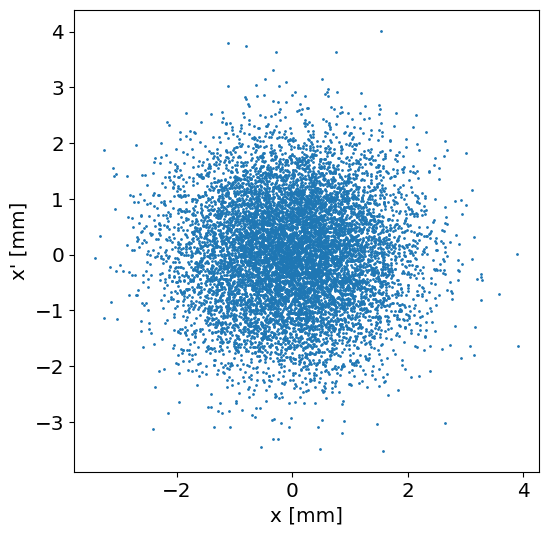

In [6]:
# We can plot them as dots in the phase space
plt.figure(figsize=(6,6))
plt.plot(X_0[0,:], X_0[1,:], '.',ms=2)
plt.xlabel('x [mm]')
plt.ylabel("x' [mm]")

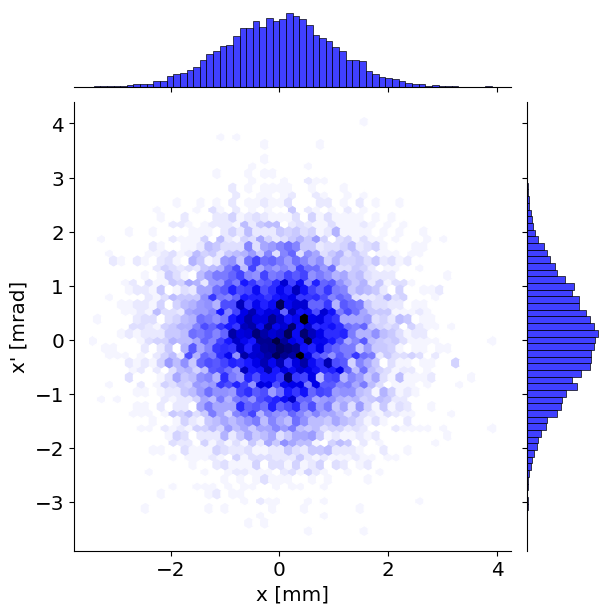

In [7]:
# you can plot it in a more fancy way
g = sns.jointplot(x=X_0[0,:], y=X_0[1,:], kind="hex", color="b")
g.set_axis_labels("x [mm]", "x' [mrad]")

> **Σημείωση:** Ο μέσος όρος των συντεταγμένων  $x$ αντιστοιχεί στη **μέση θέση της δέσμης** (ή **κεντροειδές της δέσμης** - centroid), ενώ η τυπική απόκλιση $\sigma$ των $x$ συντεταγμένων αναφέρεται ως το **μέγεθος της δέσμης** (beam size). Συνήθως, οι κατανομές των σωματιδίων στο εγκάρσιο επίπεδο είναι Γκαουσιανές ή προσεγγίζουν μια Γκαουσιανή κατανομή.


---
## 📌 Μαγνητικά Στοιχεία
- Ένας επιταχυντής αποτελείται από έναν αριθμό ηλεκτρομαγνητικών στοιχείων (δίπολα, τετράπολα, εξάπολα, κ.ά.).

- Στην γραμμική προσέγγιση, κάθε στοιχείο αναπαρίσταται με έναν πίνακα $M$ και η μεταφορά του σωματιδίου από τη θέση $s = s_0$ στη θέση $s = s_1$ γίνεται ως εξής:

    $$
    \left( \begin{array}{c} x_1 \\ x'_1 \end{array} \right) = M \cdot \left( \begin{array}{c} x_0 \\ x'_0 \end{array} \right),
    $$

    ή ισοδύναμα:

    $$
    X_1 = M \cdot X_0,
    $$

    όπου $X_0$ είναι οι αρχικές συντεταγμένες του σωματιδίου στη θέση $s_0$ και $X_1$ οι τελικές του στη θέση $s_1$ (αμέσως μετά το στοιχείο).

- Η απουσία ενός στοιχείου, δηλαδή ένας **χώρος ολίσθησης** (drift space), αναπαρίσταται επίσης ως στοιχείο. Ένας χώρος ολίσθησης αναπαρίσταται με έναν πίνακα που έχει μονάδες στην διαγώνιο και το μήκος του χώρου ολίσθησης στην ανώτερη δεξιά γωνία (Μ2-δ17):

    $$
    D = \left[ \begin{array}{cc} 1 & L \\ 0 & 1 \end{array} \right],
    $$

    όπου $L$ είναι το μήκος του χώρου ολίσθησης.


### 📝 Άσκηση 3: μεταφορά σωματιδίων σε χώρο ολίσθησης

- Μεταφέρετε $N=5$ σωματίδια με αρχικές γωνίες $x'_0=0$, αλλά διαφορετικές αρχικές θέσεις $x_0$, π.χ. $[-2,-1,0,1,2]$ mm, μέσα σε έναν χώρο ολίσθησης μήκους $L=2$ m.

- Στη συνέχεια, μεταφέρετε τα ίδια $N=5$ σωματίδια μέσω του ίδιου χώρου ολίσθησης με αρχικές θέσεις $x_0=0$, αλλά διαφορετικές αρχικές γωνίες $x'_0$, π.χ. $[-2,-1,0,1,2]$ mrad.

- Σε και τις δύο περιπτώσεις, σχεδιάστε τις συντεταγμένες $x$ των σωματιδίων ως συνάρτηση της θέσης $s$ (δηλαδή για $s_0=0$ και $s_1=L=2$).


In [8]:
# We define the drift as a numpy matrix:
L = 2 # be careful of the units! this is in m. 
D = np.array([ [1, L], 
               [0, 1] ])
print(D)

[[1 2]
 [0 1]]


In [9]:
# The initial coordinates
X_0 = np.array([ [-2e-3,-1e-3,0,1e-3,2e-3], # we need to convert the initial coordinates to meters
                 [0,0,0,0,0]])
print(f'Initial particle coordinates:\n {X_0}')

Initial particle coordinates:
 [[-0.002 -0.001  0.     0.001  0.002]
 [ 0.     0.     0.     0.     0.   ]]


In [10]:
# The final coordinates (NOTE: matrix multiplication is done with @ while * represents element by element multiplication):
X_1 = D @ X_0
print(f'Final particle coordinates:\n {X_1}')

Final particle coordinates:
 [[-0.002 -0.001  0.     0.001  0.002]
 [ 0.     0.     0.     0.     0.   ]]


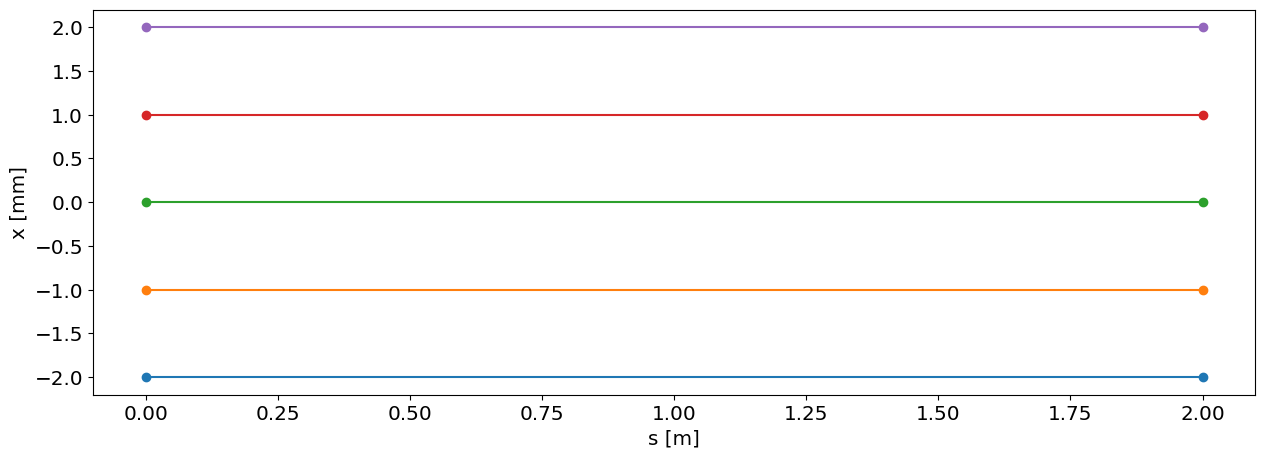

In [11]:
# We will plot for each particle the initial and final x-coordinate between 
s = [0,L] # usually s is in meters
for i in range(len(X_0[0])):
    plt.plot(s, [X_0[0,i]*1e3, X_1[0,i]*1e3], 'o-') # we plot x in mm for convenience
plt.xlabel('s [m]')
plt.ylabel('x [mm]')
plt.show()

In [12]:
# The initial coordinates
X_0 = np.array([[0,0,0,0,0], 
                [-2e-3,-1e-3,0,1e-3,2e-3]]) # we need to convert them to rad
print(f'Initial particle coordinates:\n {X_0}')

Initial particle coordinates:
 [[ 0.     0.     0.     0.     0.   ]
 [-0.002 -0.001  0.     0.001  0.002]]


In [13]:
# The final coordinates (NOTE: matrix multiplication is done with @ while * represents element by element multiplication):
X_1 = D @ X_0
print(f'Final particle coordinates:\n {X_1}')


Final particle coordinates:
 [[-0.004 -0.002  0.     0.002  0.004]
 [-0.002 -0.001  0.     0.001  0.002]]


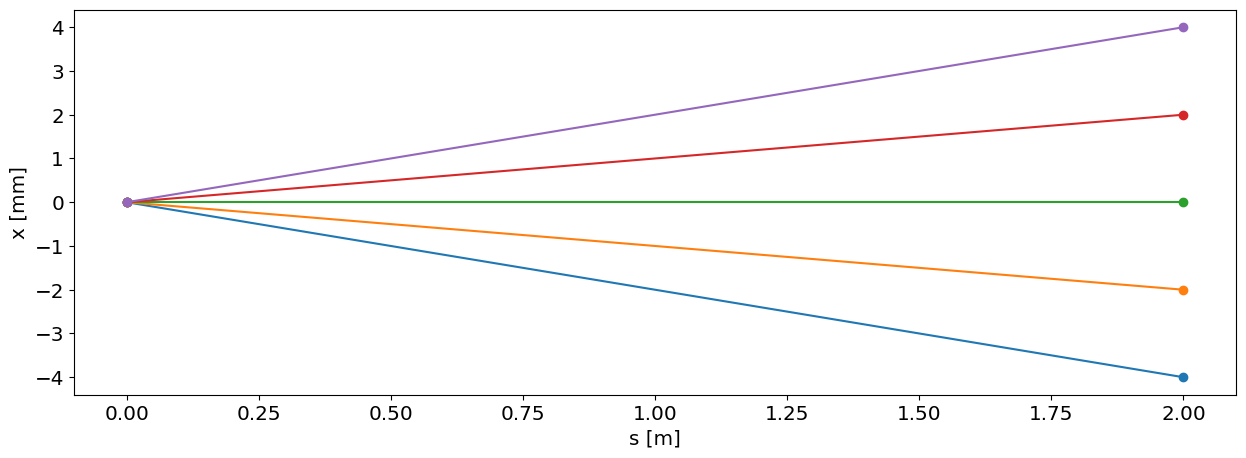

In [14]:
# We will plot for each particle the initial and final x-coordinate between 
s = [0,L] # usually s is in meters
for i in range(len(X_0[0])):
    plt.plot(s, [X_0[0,i]*1e3, X_1[0,i]*1e3], 'o-')
plt.xlabel('s [m]')
plt.ylabel('x [mm]')
plt.show()

> **Σημείωση:** Σωματίδια με $p_x\neq0$ μπορούν να χαθούν γρήγορα στην οριζόντια aperture του επιταχυντή μας (π.χ. στον σωλήνα δέσμης), αν δεν εστιάζονται!

- **Τετραπολικοί μαγνήτες** χρησιμοποιούνται για την εστίαση της δέσμης. Ωστόσο, τα τετράπολα **εστιάζουν σε ένα επίπεδο** και **αποεστιάζουν στο άλλο επίπεδο** (M1-δ54 και Μ2-δ18). Επομένως, για να επιτύχουμε εστίαση και στα δύο επίπεδα (οριζόντιο και κατακόρυφο), πρέπει να εναλλάσσουμε εστιακά και αποεστιακά τετράπολα.

- Ο πίνακας μεταφοράς ενός **λεπτού τετράπολου** (προσέγγιση thin lens) με εστιακό μήκος $\pm f$ δίνεται από (M2-δ18):

    $$
    Q=\begin{bmatrix}
    1 & 0\\
    -1/f & 1
    \end{bmatrix}.
    $$

- Θα αναπαραστήσουμε τον εστιακό τετράπολο ως $QF\equiv Q(+f)$ και τον αποεστιακό τετράπολο ως $QD\equiv Q(-f)$.


### 📝 Άσκηση 4: εστίαση σωματιδίων

- Υλοποιήστε έναν πίνακα εστίασης για τετράπολο (χρησιμοποιώντας την προσέγγιση thin lens) με εστιακό μήκος $f = 0.3$ m και δύο χώρους ολίσθησης μήκους $L_1=0.5$ m και $L_2=1$ m.

- Μεταφέρετε $N=5$ σωματίδια, με αρχικές θέσεις $x_0=0$ αλλά διαφορετικές αρχικές γωνίες $x'_0$, π.χ. $[-2,-1,0,1,2]$ mrad, πρώτα στον πρώτο χώρο ολίσθησης, έπειτα στο τετράπολο και τέλος στον δεύτερο χώρο ολίσθησης.

- Σχεδιάστε τις συντεταγμένες $x$ των σωματιδίων ως συνάρτηση της θέσης $s$.


In [17]:
# Definition of elements

# The first drift space with length 0.5 meters
L1 = 0.5
D1 = np.array([[1, L1], 
               [0, 1]])

# The focusing quadrupole
f = +0.3
QF = np.array([[1,    0], 
               [-1/f, 1]])

# The second drift space with length 1 meter
L2 = 1
D2 = np.array([[1, L2], 
               [0, 1]])

In [18]:
# The definition of particles (initial coordinates)
X_0 = np.array([[0,0,0,0,0], 
                [-2e-3,-1e-3,0,1e-3,2e-3]])
print(f'Initial particle coordinates:\n {X_0}')

Initial particle coordinates:
 [[ 0.     0.     0.     0.     0.   ]
 [-0.002 -0.001  0.     0.001  0.002]]


In [19]:
# coordinates after D1
X_1 = D1 @ X_0
# coordinates after QF
X_2 = QF @ X_1
# coordinates after D2
X_3 = D2 @ X_2

Text(0, 0.5, 'x [mm]')

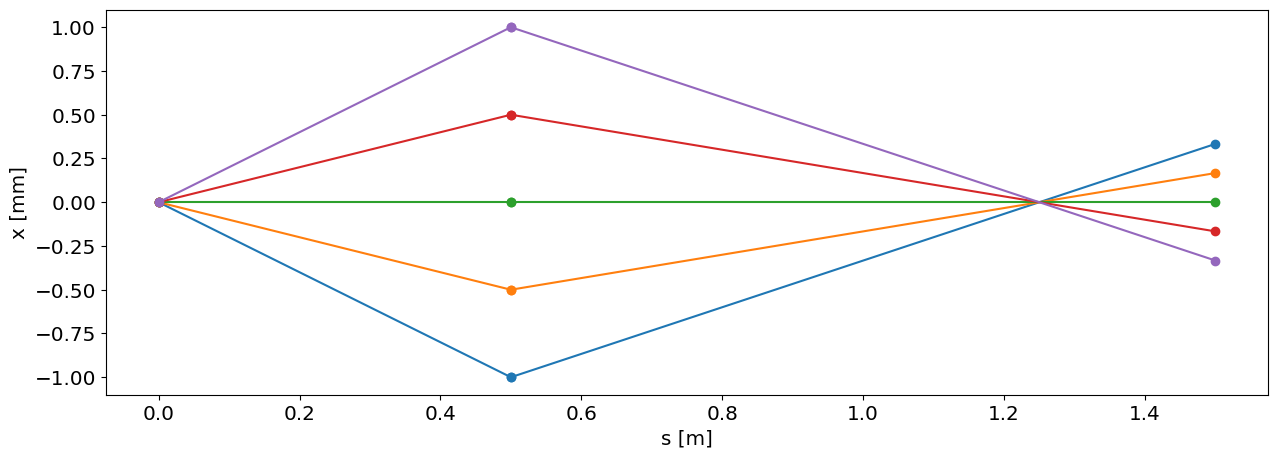

In [20]:
# We will plot for each particle the x-coordinates between 
s = [0, L1, L1, (L1+L2)]
for i in range(len(X_0[0])):
    plt.plot(s, [X_0[0,i]*1e3,X_1[0,i]*1e3,X_2[0,i]*1e3,X_3[0,i]*1e3], 'o-')
plt.xlabel('s [m]')
plt.ylabel('x [mm]')

> **Σημείωση:** Η τελική κατάσταση μπορεί να προκύψει από την αρχική αν πολλαπλασιάσουμε όλους τους πίνακες:
> $$
> X_3 = D_2 \cdot QF \cdot D_1 \cdot X_0,
> $$
> **Προσέξτε επίσης τη σειρά των πινάκων!**


---
## 📌 Simple beam lines (γραμμες δεσμης)

- Μια γραμμή δέσμης (ή ένας ολόκληρος δακτύλιος - ring) μπορεί να μοντελοποιηθεί ως μια σειρά από πίνακες:

    $$
    X_s = M_n \cdot ... \cdot M_2 \cdot M_1 \cdot X_0
    $$

- Ανεξάρτητα από τις αρχικές συντεταγμένες του σωματιδίου, μπορούμε να υπολογίσουμε έναν μοναδικό πίνακα (**ισοδύναμος πίνακας** $M_{eq.}$) που αναπαριστά ολόκληρη τη γραμμή δέσμης (ή τον δακτύλιο):

    $$
    X_s = M_n \cdot ... \cdot M_2 \cdot M_1 \cdot X_0 = M_{eq.} \cdot X_0
    $$


### 📝 Άσκηση 5: μεταφορά σωματιδίου σε γραμμή δέσμης

Δεδομένου ότι $L=1$ m και $f=0.25$ m, μεταφέρετε ένα σωματίδιο με αρχικές συντεταγμένες $x_0=1$ mm και $x'_0=0$ μέσω μιας γραμμής δέσμης που αποτελείται από:

- Έναν λεπτό εστιακό τετραπολικό μαγνήτη με εστιακό μήκος $2f$
- Ένα κενό διάστημα (drift) μήκους $L$
- Έναν λεπτό αποεστιακό τετραπολικό μαγνήτη με εστιακό μήκος $f$
- Ένα κενό διάστημα (drift) μήκους $L$
- Έναν λεπτό εστιακό τετραπολικό μαγνήτη με εστιακό μήκος $2f$

Υπολογίστε το ισοδύναμο στοιχείο της γραμμής δέσμης (δηλαδή τον πίνακα $M_{eq.}$).


In [21]:
# Definition of elements
f = 0.25
L = 1
HQF1 = np.array([[1, 0], [-1/(2*f), 1]]) # longer focusing length -> weaker focusing
D1 = np.array([[1, L], [0, 1]])
QD = np.array([[1, 0], [1/f, 1]])
D2 = np.array([[1, L], [0, 1]])
HQF2 = np.array([[1, 0], [-1/(2*f), 1]])

# inital coordinates of particle
X_0 = np.array([[1e-3], 
                [0]])

# Coordinates after each element
X_1 = HQF1 @ X_0
X_2 = D1 @ X_1
X_3 = QD @ X_2
X_4 = D2 @ X_3
X_5 = HQF2 @ X_4

Text(0, 0.5, 'x [mm]')

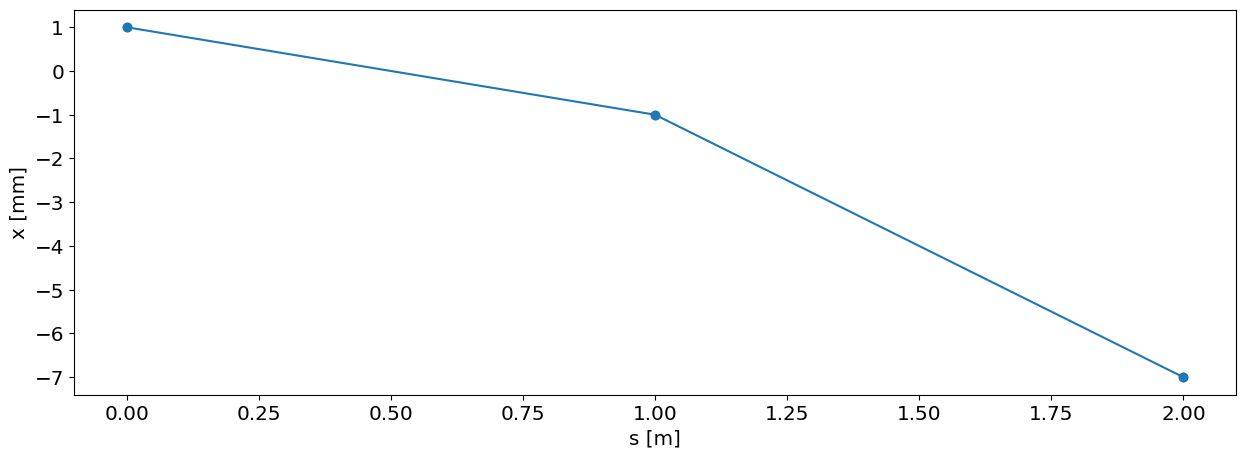

In [22]:
# Plot particle coordinates at each element
s = [0, 0, L, L, (L+L), (L+L)]
plt.plot(s, np.array([X_0[0],X_1[0],X_2[0],X_3[0],X_4[0],X_5[0]])*1e3, 'o-')
plt.xlabel('s [m]')
plt.ylabel('x [mm]')

In [23]:
# the equivalent matrix
Meq = HQF2 @ D2 @ QD @ D1 @ HQF1
print(Meq)

[[-7.  6.]
 [ 8. -7.]]


---
## 📌  Παρένθεση: Μια βιβλιοθήκη tracking

Θα ορίσουμε μερικές συναρτήσεις Python για να διευκολύνουμε τον ορισμό πινάκων, γραμμών δέσμης και τη μεταφορά (tracking) σωματιδίων, που θα είναι χρήσιμες για τις υπόλοιπες ασκήσεις.



In [24]:
# Modeling of a drift
def D(L):
    '''Returns a list containing a single "drift" of length L'''
    # NB: we return a list with a dict
    # the dict contains the matrix (the transformation)
    # and the element length 
    return [{'matrix':np.array([[1, L],[0, 1]]), 'length':L}] 


# Modeling of a thin quadrupole
def Q(f):
    '''Returns a list containing a quadrupole with focal length f'''
    # NB: we return a list with a dict
    # the dict contains the matrix (the transformation)
    # and the element length 
    return [{'matrix':np.array([[1, 0],[-1/f, 1]]), 'length':0}]


# Μεταφορά σωματιδίων κατά μήκος μιας γραμμής δέσμης (tracking)
def transportParticles(X_0, beamline, s_0=0):
    '''Track the particle(s) `X_0` along the given `beamline`. 
    If needed, one can specify an initial longitudinal position `s_0`, otherwise set to 0.

    It will return a dictionary containing the following key:values
       'x': a NxM numpy array with the M-particles x position for all N-elements of the beamline
       'xp': a NxM numpy array with the M-particles x' angles for all N-elements of the beamline
       's': a N-long numpy array with the longitudinal position of the N-elements of the beamline
       'coords': a Nx2xM numpy array with all M-particles coordinates (both x and x') at all N-elements of the beamline
    
    Disclaimer: if beamline is made of 5 elements, the output will have 5+1 "elements" as it will also 
                return include the initial particle coordinates.
    '''
    coords = [X_0]
    s = [s_0]
    for element in beamline:
        coords.append(element['matrix'] @ coords[-1])
        s.append(s[-1] + element['length']) 
    coords = np.array(coords)
    s = np.array(s)
    return {'x':  coords[:,0,:], # [s_idx, particle_idx]
            'xp': coords[:,1,:], # [s_idx, particle_idx]
            's':  s,   # [s_idx]
            'coords': coords,}   # [s_idx, coord_idx, particle_idx]


# Υπολογισμός του "ισοδύναμου στοιχείου" μιας γραμμής δέσμης
def getEquivalentElement(beamline):
    '''Returns the single element which is equivalent of the given beamline'''
    # we start from an identity matrix (np.eye)
    # with the same dimension of the matrix of the
    # first element of the beamline
    equivalentElement = np.eye(beamline[0]['matrix'].shape[0])
    length = 0
    # NB: we reverse the order of the beamline ([-1::-1])
    for elements in beamline[-1::-1]:
        # we multiply the matrices 
        equivalentElement = equivalentElement @ elements['matrix']
        # and we add the lengths
        length = length + elements['length']
    # we return the dict with the "usual" keys (matrix and length) embedded in a
    #  list (with a single element), as for the definition of the D and Q functions
    return [{'matrix':equivalentElement, 'length':length}]

In [25]:
# Example: a drift of L=2 m can be generated as:
D(2)

[{'matrix': array([[1, 2],
         [0, 1]]),
  'length': 2}]

In [26]:
# e.g. representation of a beamline made of two drifts of different length:
D(1) + D(5)

[{'matrix': array([[1, 1],
         [0, 1]]),
  'length': 1},
 {'matrix': array([[1, 5],
         [0, 1]]),
  'length': 5}]

In [27]:
# Now the definition of the beamline of exercise 6 is much easier:
f = 0.25
L = 1
beamline = Q(2*f)+D(L)+Q(-f)+D(L)+Q(2*f)
beamline

[{'matrix': array([[ 1.,  0.],
         [-2.,  1.]]),
  'length': 0},
 {'matrix': array([[1, 1],
         [0, 1]]),
  'length': 1},
 {'matrix': array([[1., 0.],
         [4., 1.]]),
  'length': 0},
 {'matrix': array([[1, 1],
         [0, 1]]),
  'length': 1},
 {'matrix': array([[ 1.,  0.],
         [-2.,  1.]]),
  'length': 0}]

In [28]:
# Example: equivalent element of the FODO of exercise 6
f = 0.25
L = 1
bealine = Q(2*f)+D(L)+Q(-f)+D(L)+Q(2*f)
getEquivalentElement(beamline)

[{'matrix': array([[-7.,  6.],
         [ 8., -7.]]),
  'length': 2}]

Text(0, 0.5, 'x [mm]')

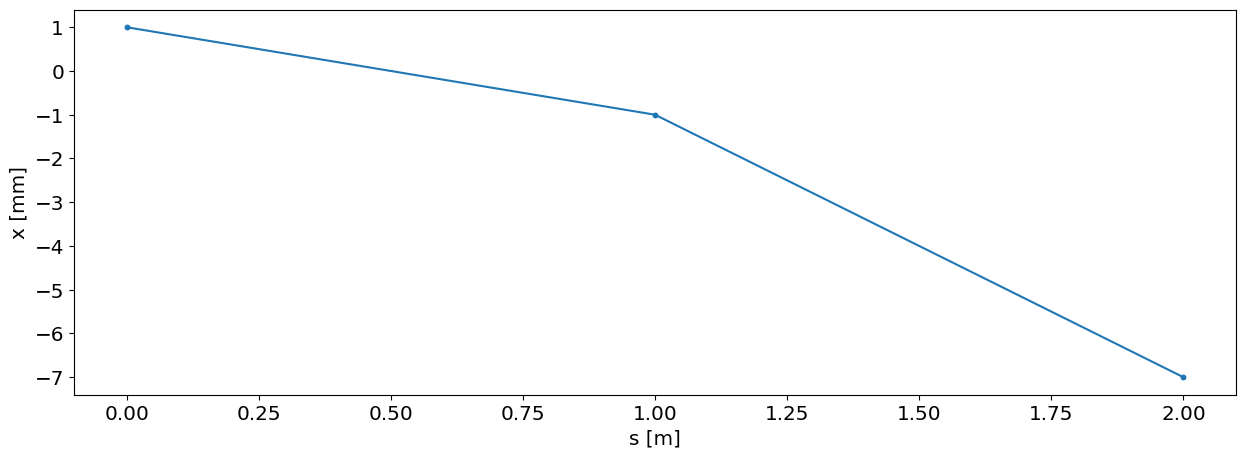

In [29]:
# Repeating exercise 5 with these functions is more compact

# beamline definition
f = 0.25
L = 1
beamline = Q(2*f)+D(L)+Q(-f)+D(L)+Q(2*f)

# inital coordinates of particle
X_0 = np.array([[1e-3], 
                [0]])

# tracking
tracked_data = transportParticles(X_0, beamline)

# Plot particle coordinates at each element
plt.plot(tracked_data['s'], tracked_data['x']*1e3, '.-')
plt.xlabel('s [m]')
plt.ylabel('x [mm]')

### **Όλες αυτές οι συναρτήσεις είναι διαθέσιμες στο αρχείο tracking_library.py, το οποίο θα εισάγουμε στα επόμενα notebooks.**